In [1]:
%load_ext autoreload
%autoreload 2

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from scipy.stats import pearsonr
from glob import glob
from tqdm import tqdm

import matplotlib.pyplot as plt

from utils_data import get_flipflop_labels

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
# get config from config/default.yaml
import yaml
with open('config/default.yaml', 'r') as f:
    config = yaml.load(f, Loader=yaml.FullLoader)


# convert dict into a class
class FlatNamespace:
    def __init__(self, **kwargs):
        # __dict__ holds all of an object’s instance attributes
        # recursively convert all dicts into FlatNamespace
        self.__dict__.update(kwargs)
        for key, value in self.__dict__.items():
            if isinstance(value, dict):
                self.__dict__[key] = FlatNamespace(**value)


for key, value in config.items():
    if isinstance(value, dict):
        config[key] = FlatNamespace(**value)

config = FlatNamespace(**config)



# Prepare data & model

In [3]:
""" 
Get data -- we only care about the val set
"""

from utils_data import get_loaders

length = 128
n_states = 2
config.data.length = length
config.data.n_states = n_states
config.data.n_samples_train = 102400
config.data.n_samples_val = 8192
config.data.p_ignores_train = "0.5;0.8;0.9;0.99"
config.data.p_ignores_val = "0.5;0.8;0.9;0.99"
config.data.batch_size = 32
config.data.eval_batch_size = 128

train_loader, val_loader = get_loaders(config.data)


In [4]:
# Check a batch from val_loader
i = 116
config.data.n_ignores_val = str(i)
_, val_loader = get_loaders(config.data)
batch = next(iter(val_loader))
xv, yv = batch[0].cuda().long(), batch[1].cuda().long()

(xv == 0).float().mean()

tensor(0.8994, device='cuda:0')

In [4]:
from utils_model import get_model

config.model.attn_layers.dim = 256
config.model.attn_layers.depth = 1
config.model.attn_layers.heads = 1

ckpt_dir = "checkpoints"
# run = 'L1W256H1_lr1e-3_seedM7_seedD8_20250716_235927'


# expr_type = 'p_ignores_every0.07'
# expr_type = 'n_ignores_1,125'
# expr_type = 'n_ignores_64'
# expr_type = 'n_ignores_every10'
# expr_type = 'n_ignores_1,100,127'
# expr_type = 'fixed_set_lr0.001_adam'

# expr_type = 'equal_intvls'
expr_type = 'equal_intvls_nDense100'

print(expr_type)

if expr_type == 'p_ignores_every0.07':
    run = '_1_20250721_121847'
elif expr_type == 'n_ignores_1,120':
    run = '_1_20250718_163647' # trained for 8192 * 100 samples
elif expr_type == 'n_ignores_1,125':
    # trained till saturation
    # run = '_1_20250718_174419' # run1
    # run = '_1_20250718_174434' # run2
    # Intermediate ckpts saved
    run = '_1_20250719_170123' 
elif expr_type == 'n_ignores_64':
    # trained till saturation
    run = '_1_20250718_174812'
    # run = '_1_20250718_174807'
elif expr_type == 'n_ignores_every10':
    run = '_1_20250721_121139'
elif expr_type == 'n_ignores_1,100,127':
    run = '_1_20250721_130147'
elif expr_type == 'fixed_set_lr0.001_adam':
    run = '_1_20250722_214848'
elif expr_type == 'equal_intvls':
    run = '_1_20250722_235828'
elif expr_type == 'equal_intvls_nDense100':
    run = '_1_20250723_002050'
 
fckpt = os.path.join(ckpt_dir, run, 'best.pth')
config.model.load_ckpt = 1
config.model.ckpt_path = fckpt

num_tokens = val_loader.dataset.n_states + 1 # +1 for the ignore
model = get_model(config, num_tokens)
model = model.to(device)

equal_intvls_nDense100
Loading checkpoint from checkpoints/_1_20250723_002050/best.pth


# Evaluate

In [5]:
def eval_model(model, loader, n_samples=-1):
    model.eval()
    val_losses, val_accs = [], []
    samples_count = 0
    for batch in loader:
        xv, yv = batch[0].cuda().long(), batch[1].cuda().long()
        logits_v = model(xv)

        # eval loss & acc
        loss_v = nn.CrossEntropyLoss()(logits_v.reshape(-1, logits_v.size(-1)), yv.reshape(-1))
        val_losses.append(loss_v.item())
        logits_v = logits_v[:, :, 1:] # ignore the ignore state
        acc_v = (torch.argmax(logits_v, dim=-1)+1 == yv).float().mean().item()
        val_accs.append(acc_v)

        if n_samples > 0 and samples_count >= n_samples:
            break
    return np.mean(val_losses), np.mean(val_accs)

In [7]:
import matplotlib.pyplot as plt

def plot_losses_accs(losses, accs, eval_type, title=''):
  fig, ax = plt.subplots(1, 2, figsize=(20, 10))

  if eval_type == 'n_ignores':
    # losses, accs = losses_n_ignores, accs_n_ignores
    ax[0].set_xlabel('n_ignores_val')
    ax[1].set_xlabel('n_ignores_val')
  else:
    # losses, accs = losses_p_ignores, accs_p_ignores
    ax[0].set_xlabel('p_ignores_val')
    ax[1].set_xlabel('p_ignores_val')

  ax[0].plot(list(losses.keys()), list(losses.values()))
  ax[0].set_title('Loss')
  ax[0].set_ylabel('loss')

  ax[1].plot(list(accs.keys()), list(accs.values()), marker='o')
  ax[1].set_title('Accuracy')
  ax[1].set_ylabel('accuracy')
  if title:
    fig.suptitle(title)
  plt.show()


In [7]:
"""
Eval with different p_ignores_val
"""
eval_type = 'p_ignores'
losses_p_ignores = {}
accs_p_ignores = {}
for i in np.arange(0.01, 1, 0.05):
  config.data.n_ignores_val = "" # setting to empty string since this overrides p_ignores_val
  config.data.p_ignores_val = str(i)
  _, val_loader = get_loaders(config.data)
  val_loss, val_acc = eval_model(model, val_loader)
  losses_p_ignores[i] = val_loss
  accs_p_ignores[i] = val_acc


**Evaluate all ckpts**

In [ ]:
curr_ckpt_dir = os.path.join(ckpt_dir, run)
print(curr_ckpt_dir)
ckpts = glob(os.path.join(curr_ckpt_dir, 'step*.pth'))
ckpts = sorted(ckpts, key=lambda x: int(x.split('/')[-1].replace('step', '').replace('.pth', '')))
print(f"Evaluating {len(ckpts)} ckpts")

for ckpt in tqdm(ckpts):
    config.model.load_ckpt = 1
    config.model.ckpt_path = ckpt
    assert os.path.exists(config.model.ckpt_path), print(config.model.ckpt_path)
    model = get_model(config, num_tokens)
    model = model.to(device)

    eval_type = 'p_ignores'
    losses_p_ignores = {}
    accs_p_ignores = {}
    for i in np.arange(0.01, 1, 0.05):
      config.data.n_ignores_val = "" # setting to empty string since this overrides p_ignores_val
      config.data.p_ignores_val = str(i)
      _, val_loader = get_loaders(config.data)
      val_loss, val_acc = eval_model(model, val_loader)
      losses_p_ignores[i] = val_loss
      accs_p_ignores[i] = val_acc

    plot_losses_accs(losses_p_ignores, accs_p_ignores, eval_type, title=f'{ckpt}')



In [6]:
"""
Eval with different n_ignores_val
"""

eval_type = 'n_ignores'

losses_n_ignores = {}
accs_n_ignores = {}
for i in range(1, 128, 5):
  config.data.n_ignores_val = str(i)
  _, val_loader = get_loaders(config.data)
  val_loss, val_acc = eval_model(model, val_loader)
  losses_n_ignores[i] = val_loss
  accs_n_ignores[i] = val_acc


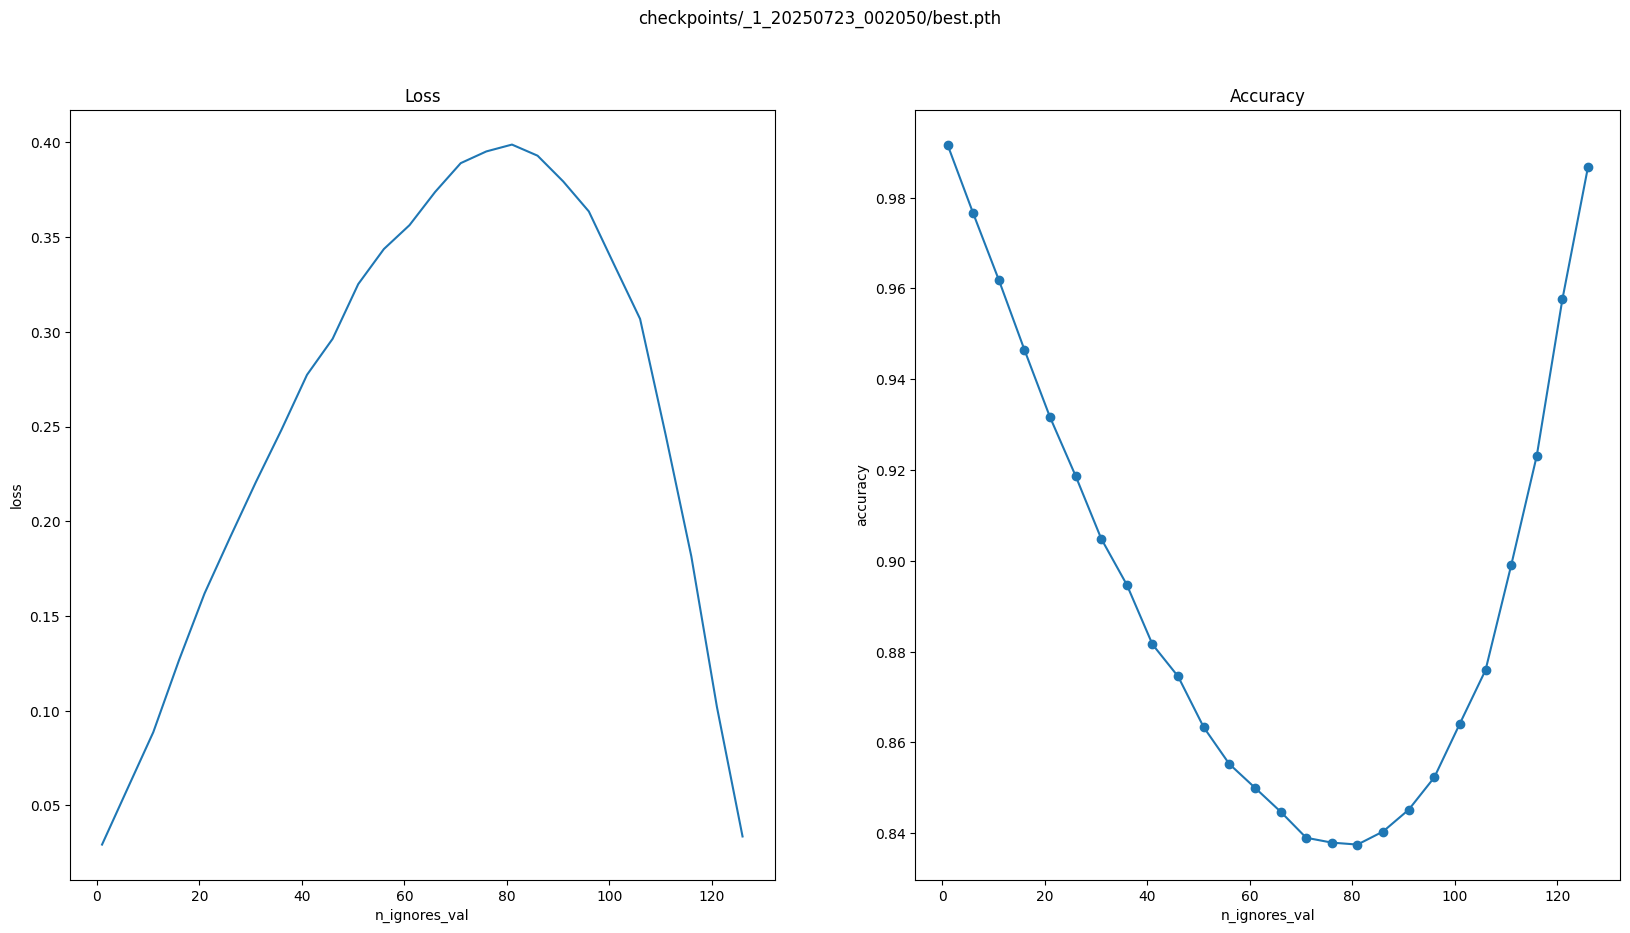

In [8]:
if eval_type == 'n_ignores':
    losses = losses_n_ignores 
    accs = accs_n_ignores
else:
    losses = losses_p_ignores
    accs = accs_p_ignores
plot_losses_accs(losses, accs, eval_type, title=f'{fckpt}')

# Correlation check

In [32]:
# get the entropy at each position
batch = next(iter(val_loader))
xv, yv = batch[0].cuda().long(), batch[1].cuda().long()
with torch.no_grad():
    logits = model(xv)
prob = F.softmax(logits, dim=-1)
correct = (torch.argmax(logits, dim=-1) == yv).float()
entropy = -torch.sum(prob * torch.log(prob), dim=-1)
argmax_prob = torch.max(prob, dim=-1).values


# get the distance to the most recent write at each position
B, T = xv.shape
write_mask = xv.ne(0)
# a [0,1,2,...,T-1] row, expanded over batch
idx = torch.arange(T, device=xv.device).unsqueeze(0).expand(B, T)
# keep idx for writes, else zero
write_pos = torch.where(write_mask, idx, torch.zeros_like(idx))
# for each t, copy the last write index until the next write
last_pos = write_pos.cummax(dim=1).values                 
# distance is current index minus last write index
dist = idx - last_pos 

# number of writes so far
n_writes_till_now = (xv != 0).cumsum(dim=1)
# positions
positions = np.arange(T).reshape(1, -1).repeat(B, axis=0)


entropy, dist, correct, argmax_prob, n_writes_till_now = entropy.cpu(), dist.cpu(), correct.cpu(), argmax_prob.cpu(), n_writes_till_now.cpu()
entropy, dist, correct, argmax_prob, n_writes_till_now = entropy.reshape(-1), dist.reshape(-1), correct.reshape(-1), argmax_prob.reshape(-1), n_writes_till_now.reshape(-1)
positions = positions.reshape(-1)

In [37]:
print("Correlation with correct")
p, r = pearsonr(entropy, correct)
print(f'entropy vs correct: corr={p:.4f}, p-value={r}')
p, r = pearsonr(argmax_prob, correct)
print(f'argmax_prob vs correct: corr={p:.4f}, p-value={r}')
p, r = pearsonr(dist, correct)
print(f'dist vs correct: corr={p:.4f}, p-value={r}')
p, r = pearsonr(n_writes_till_now, correct)
print(f'n_writes_till_now vs correct: corr={p:.4f}, p-value={r}')
p, r = pearsonr(positions, correct)
print(f'positions vs correct: corr={p:.4f}, p-value={r}')
print()

print("Correlation with dist")
p, r = pearsonr(entropy, dist)
print(f'entropy vs dist: corr={p:.4f}, p-value={r}')
p, r = pearsonr(argmax_prob, dist)
print(f'argmax_prob vs dist: corr={p:.4f}, p-value={r}')
print()




Correlation with correct
entropy vs correct: corr=-0.4388, p-value=0.0
argmax_prob vs correct: corr=0.4078, p-value=0.0
dist vs correct: corr=-0.1707, p-value=2.531654314370277e-107
n_writes_till_now vs correct: corr=0.0245, p-value=0.0016796126887228834
positions vs correct: corr=0.0238, p-value=0.002312344581202976

Correlation with dist
entropy vs dist: corr=0.3904, p-value=0.0
argmax_prob vs dist: corr=-0.3204, p-value=0.0



In [38]:
def plot_scatter(x, y, correct_mask, key1, key2):
    fig, ax = plt.subplots(1, 2, figsize=(20, 10))
    ax[0].scatter(x.cpu().numpy()[correct_mask], y.cpu().numpy()[correct_mask], c='blue', alpha=0.5)
    ax[0].set_title(f'{key1} vs {key2} (correct samples)')
    ax[1].scatter(x.cpu().numpy()[~correct_mask], y.cpu().numpy()[~correct_mask], c='red', alpha=0.5)
    ax[1].set_title(f'{key1} vs {key2} (incorrect samples)')
    ax[0].set_xlabel(key1)
    ax[0].set_ylabel(key2)
    ax[1].set_xlabel(key1)
    ax[1].set_ylabel(key2)
    plt.show()

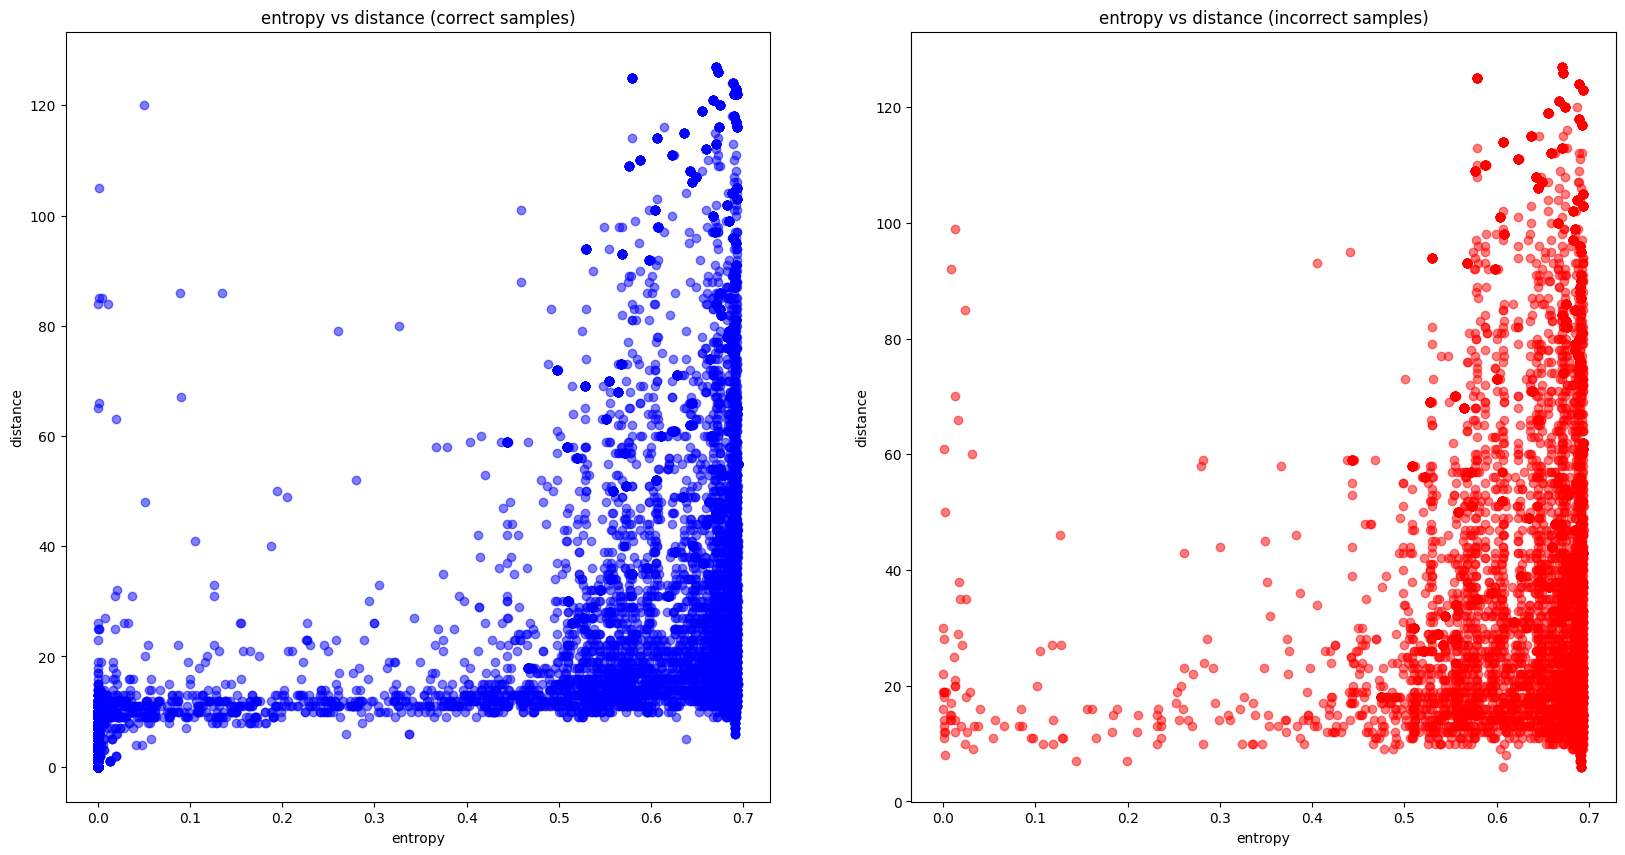

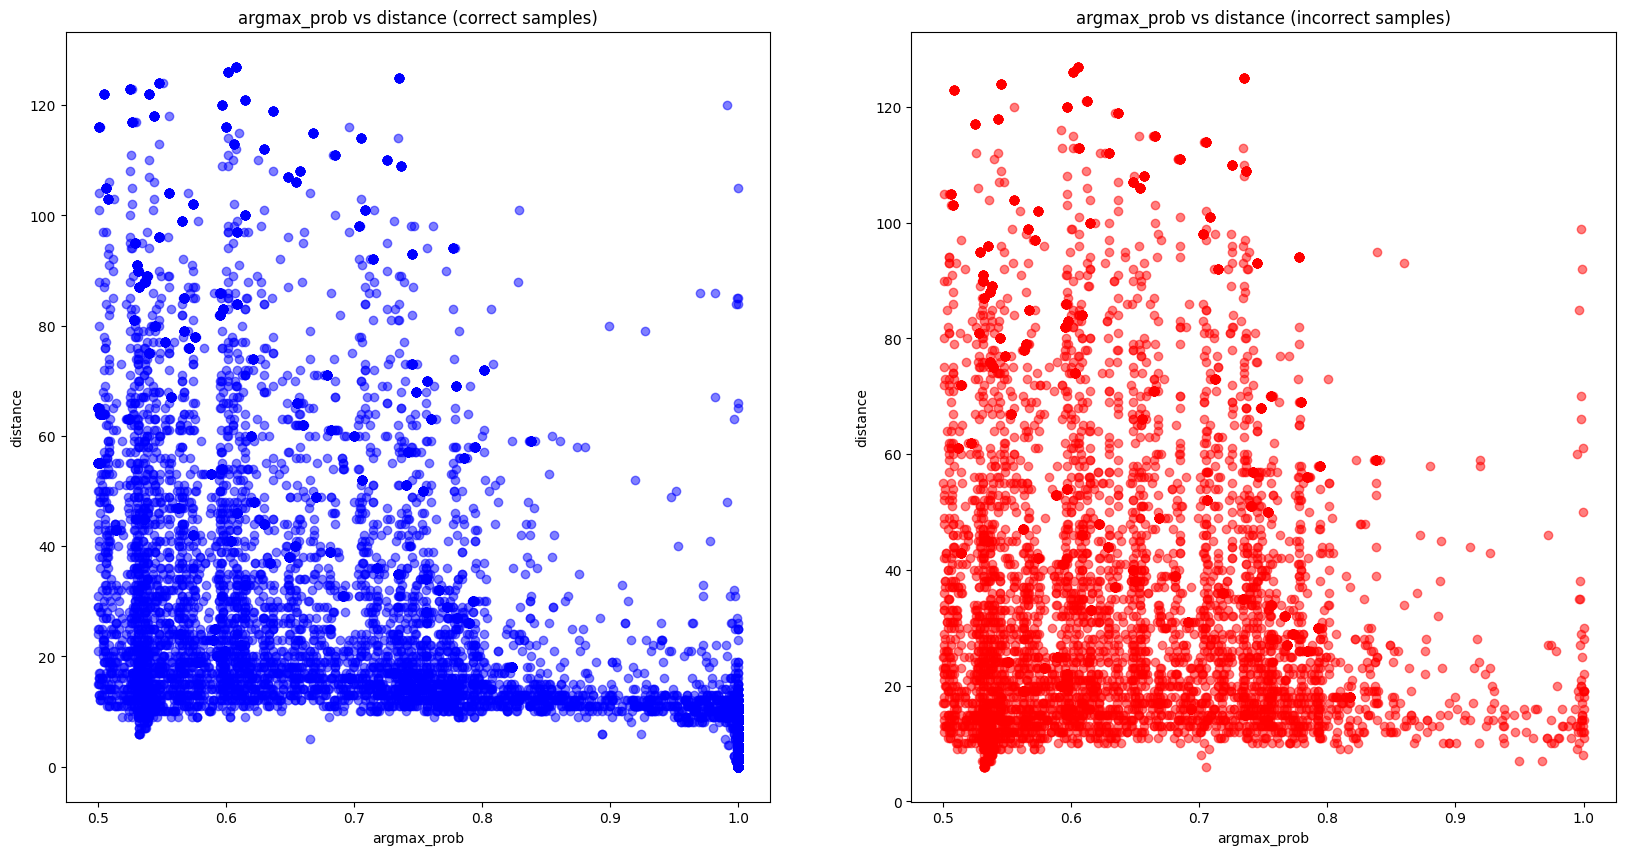

In [41]:
""" 
Scatter plots
"""
correct_mask = correct.cpu().numpy() == 1
plot_scatter(entropy, dist, correct_mask, 'entropy', 'distance')
plot_scatter(argmax_prob, dist, correct_mask, 'argmax_prob', 'distance')

Text(0, 0.5, 'Distance')

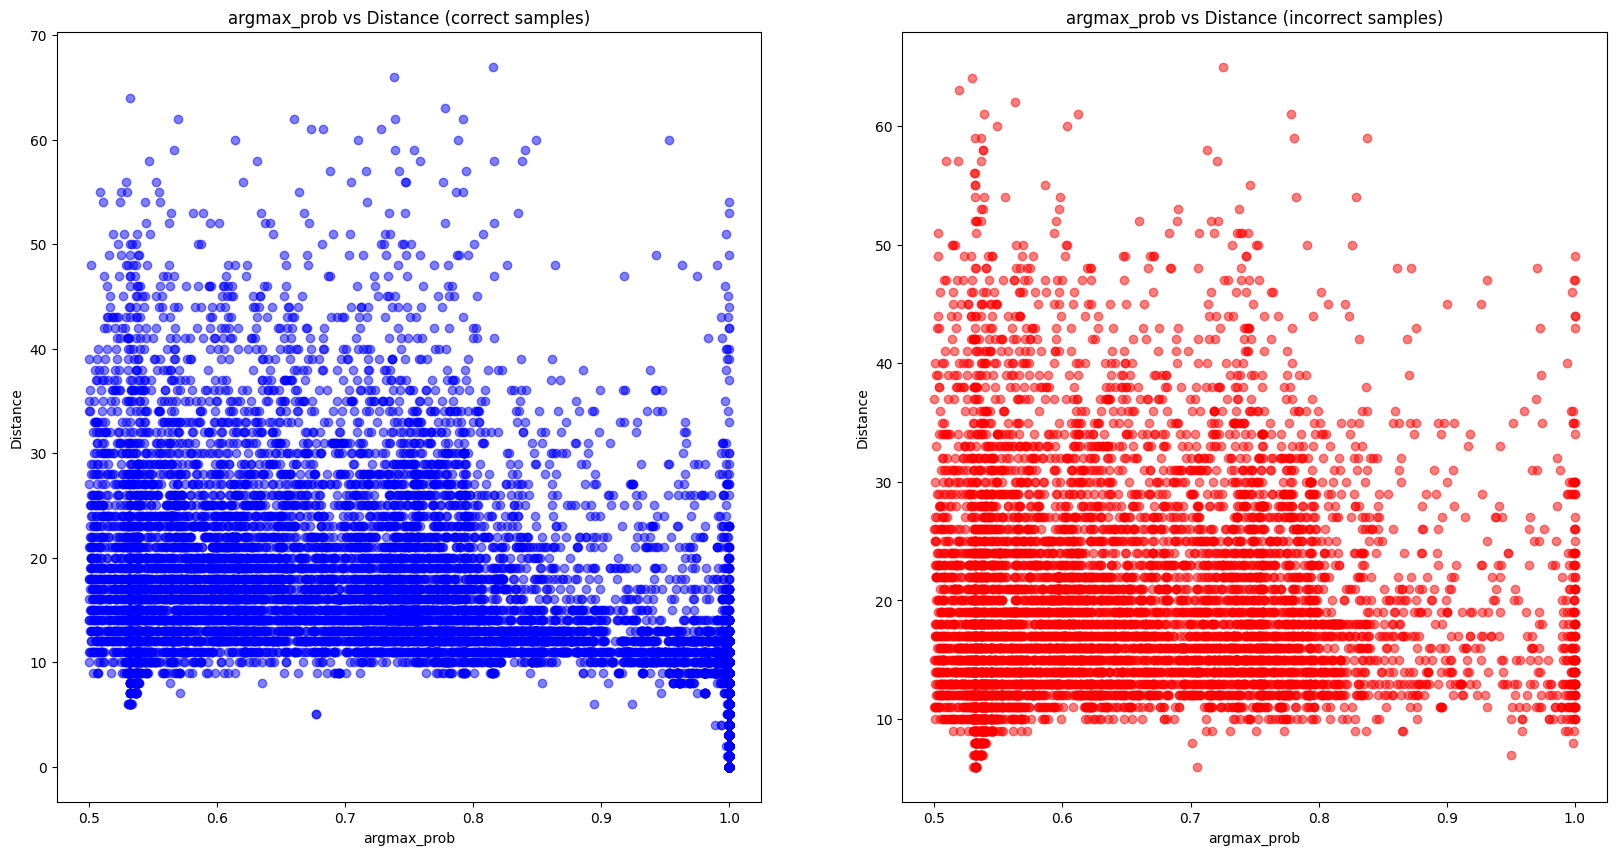

In [34]:
""" 
Scatter plot of argmax_prob vs distance
"""

fig, ax = plt.subplots(1, 2, figsize=(20, 10))

correct_mask = correct.cpu().numpy() == 1
ax[0].scatter(argmax_prob.cpu().numpy()[correct_mask], dist.cpu().numpy()[correct_mask], c='blue', alpha=0.5)
ax[0].set_title('argmax_prob vs Distance (correct samples)')
ax[1].scatter(argmax_prob.cpu().numpy()[~correct_mask], dist.cpu().numpy()[~correct_mask], c='red', alpha=0.5)
ax[1].set_title('argmax_prob vs Distance (incorrect samples)')
ax[0].set_xlabel('argmax_prob')
ax[0].set_ylabel('Distance')
ax[1].set_xlabel('argmax_prob')
ax[1].set_ylabel('Distance')


# A small MLP to predict which sequences are wrong?

In [17]:
""" 
Update the data loader
""" 

config.data.n_ignores_train = '0;40;80;125'
config.data.n_ignores_val = '80'
config.data.batch_size = 32
config.data.eval_batch_size = 128

train_loader, val_loader = get_loaders(config.data)

In [20]:
""" 
Prepare the predictor model
""" 

pred_input_type = 'logits'
if pred_input_type == 'sequence':
    return_logits_and_embeddings = False
    mlp_in_dim = length
elif pred_input_type == 'logits':
    return_logits_and_embeddings = False
    mlp_in_dim = config.data.n_states + 1
elif pred_input_type == 'embeddings':
    return_logits_and_embeddings = True
    mlp_in_dim = config.model.attn_layers.dim
else:
    raise ValueError(f'Invalid pred_type: {pred_type}')

pred_output_type = 'correctness_per_position'
if pred_output_type == 'incorrect_percent':
    mlp_out_dim = 1 # applied to the entire sequence
    loss_fn = nn.MSELoss()
elif pred_output_type == 'correctness_per_position':
    mlp_out_dim = 2 # applied position-wise
    loss_fn = nn.CrossEntropyLoss()
else:
    raise ValueError(f'Invalid pred_output_type: {pred_output_type}')



# Get a small MLP & optimizer
hidden_dim = 128

mlp_pred = nn.Sequential(
    nn.Linear(mlp_in_dim, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, mlp_out_dim),
    # nn.Sigmoid()
).to(device)

lr = 0.001
optimizer = torch.optim.Adam(mlp_pred.parameters(), lr=lr, betas=(0.9, 0.99))
# lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)


In [21]:
X_MEAN = None
X_STD = None


n_epochs = 5
losses_train, losses_val = [], []
accs_train, accs_val = [], []
step = 0
eval_interval = 500

for epoch in range(n_epochs):
    for batch in train_loader:
        x, y = batch[0].to(device).long(), batch[1].to(device).long()
        step += 1
        # calculate the number of incorrect positions per sequence
        with torch.no_grad():
            ret = model(x, return_logits_and_embeddings=return_logits_and_embeddings)
            if return_logits_and_embeddings:
                logits, embeddings = ret
            else:
                logits = ret
            pred = torch.argmax(logits, dim=-1)
        
        # use the MLP to predict the incorrect percent
        if pred_input_type == 'sequence':
            x_mlp = x.float()
        elif pred_input_type == 'logits':
            x_mlp = logits.float()
        elif pred_input_type == 'embeddings':
            x_mlp = embeddings.float()

        if X_MEAN is None: # estimate the mean and std using the first batch
            X_MEAN = x_mlp.mean(dim=0)
            X_STD = x_mlp.std(dim=0)
        x_mlp = (x_mlp - X_MEAN) / X_STD
        if pred_output_type == 'incorrect_percent':
            pred_incorrect_percent = mlp_pred(x_mlp)
            incorrect_percent = (pred != y).float().mean(dim=1)
            loss = loss_fn(pred_incorrect_percent, incorrect_percent)
        elif pred_output_type == 'correctness_per_position':
            x_mlp = x_mlp.reshape(-1, x_mlp.shape[-1])
            pred_correctness_per_position_logits = mlp_pred(x_mlp)
            correct_mask = (pred == y).long().reshape(-1)
            loss = loss_fn(pred_correctness_per_position_logits, correct_mask)
            # get accuracy
            pred_correctness_per_position = pred_correctness_per_position_logits.argmax(dim=-1)
            acc = (pred_correctness_per_position == correct_mask).float().mean()
            accs_train.append(acc.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses_train.append(loss.item())

        # lr scheduler
        # lr_scheduler.step()

        if step % eval_interval == 0 or step == len(train_loader) - 1 or step == 1:
            # evaluate the model
            curr_losses_val = []
            with torch.no_grad():
                for batch in val_loader:
                    x, y = batch[0].to(device).long(), batch[1].to(device).long()
                    ret = model(x, return_logits_and_embeddings=return_logits_and_embeddings)
                    if return_logits_and_embeddings:
                        logits, embeddings = ret
                    else:
                        logits = ret
                    pred = torch.argmax(logits, dim=-1)

                    if pred_input_type == 'sequence':
                        x_mlp = x.float()
                    elif pred_input_type == 'logits':
                        x_mlp = logits.float()
                    elif pred_input_type == 'embeddings':
                        x_mlp = embeddings.float()
                    x_mlp = (x_mlp - X_MEAN) / X_STD
                    if pred_output_type == 'incorrect_percent':
                        incorrect_percent = (pred != y).float().mean(dim=1).squeeze(-1)
                        pred_incorrect_percent = mlp_pred(x_mlp).squeeze(-1)
                        loss = loss_fn(pred_incorrect_percent, incorrect_percent)
                    elif pred_output_type == 'correctness_per_position':
                        x_mlp = x_mlp.reshape(-1, x_mlp.shape[-1])
                        pred_correctness_per_position_logits = mlp_pred(x_mlp)
                        correct_mask = (pred == y).long().reshape(-1)
                        loss = loss_fn(pred_correctness_per_position_logits, correct_mask)
                        # get accuracy
                        pred_correctness_per_position = pred_correctness_per_position_logits.argmax(dim=-1)
                        acc = (pred_correctness_per_position == correct_mask).float().mean()
                        accs_val.append(acc.item())

                    curr_losses_val.append(loss.item())
            losses_val.append(np.mean(curr_losses_val))
            print(f'Epoch {epoch}, Step {step}, Loss {loss.item()}')

# plt.plot(losses_train, marker='o')
# plt.show()
    


Epoch 0, Step 1, Loss 0.6808929443359375
Epoch 0, Step 500, Loss 0.34532442688941956
Epoch 0, Step 1000, Loss 0.34681153297424316
Epoch 0, Step 1500, Loss 0.346517950296402
Epoch 0, Step 2000, Loss 0.33819887042045593
Epoch 0, Step 2500, Loss 0.34193313121795654
Epoch 0, Step 3000, Loss 0.34042415022850037
Epoch 0, Step 3199, Loss 0.3374905586242676
Epoch 1, Step 3500, Loss 0.33773180842399597
Epoch 1, Step 4000, Loss 0.34034082293510437
Epoch 1, Step 4500, Loss 0.3359619081020355
Epoch 1, Step 5000, Loss 0.33697283267974854
Epoch 1, Step 5500, Loss 0.3373643457889557
Epoch 1, Step 6000, Loss 0.3363538086414337
Epoch 2, Step 6500, Loss 0.332798570394516
Epoch 2, Step 7000, Loss 0.3377951681613922
Epoch 2, Step 7500, Loss 0.3417868912220001
Epoch 2, Step 8000, Loss 0.33422985672950745
Epoch 2, Step 8500, Loss 0.33739373087882996
Epoch 2, Step 9000, Loss 0.3328169882297516
Epoch 2, Step 9500, Loss 0.3360590636730194
Epoch 3, Step 10000, Loss 0.3399745523929596
Epoch 3, Step 10500, Loss 0

In [20]:
batch = next(iter(val_loader))
x, y = batch[0].to(device).long(), batch[1].to(device).long()
with torch.no_grad():
    logits = model(x)
    pred = torch.argmax(logits, dim=-1)
    incorrect_percent = (pred != y).float().mean(dim=1)
print(incorrect_percent.mean())
print(incorrect_percent.std())

tensor(0.1274, device='cuda:0')
tensor(0.1512, device='cuda:0')


Text(0, 0.5, 'Loss')

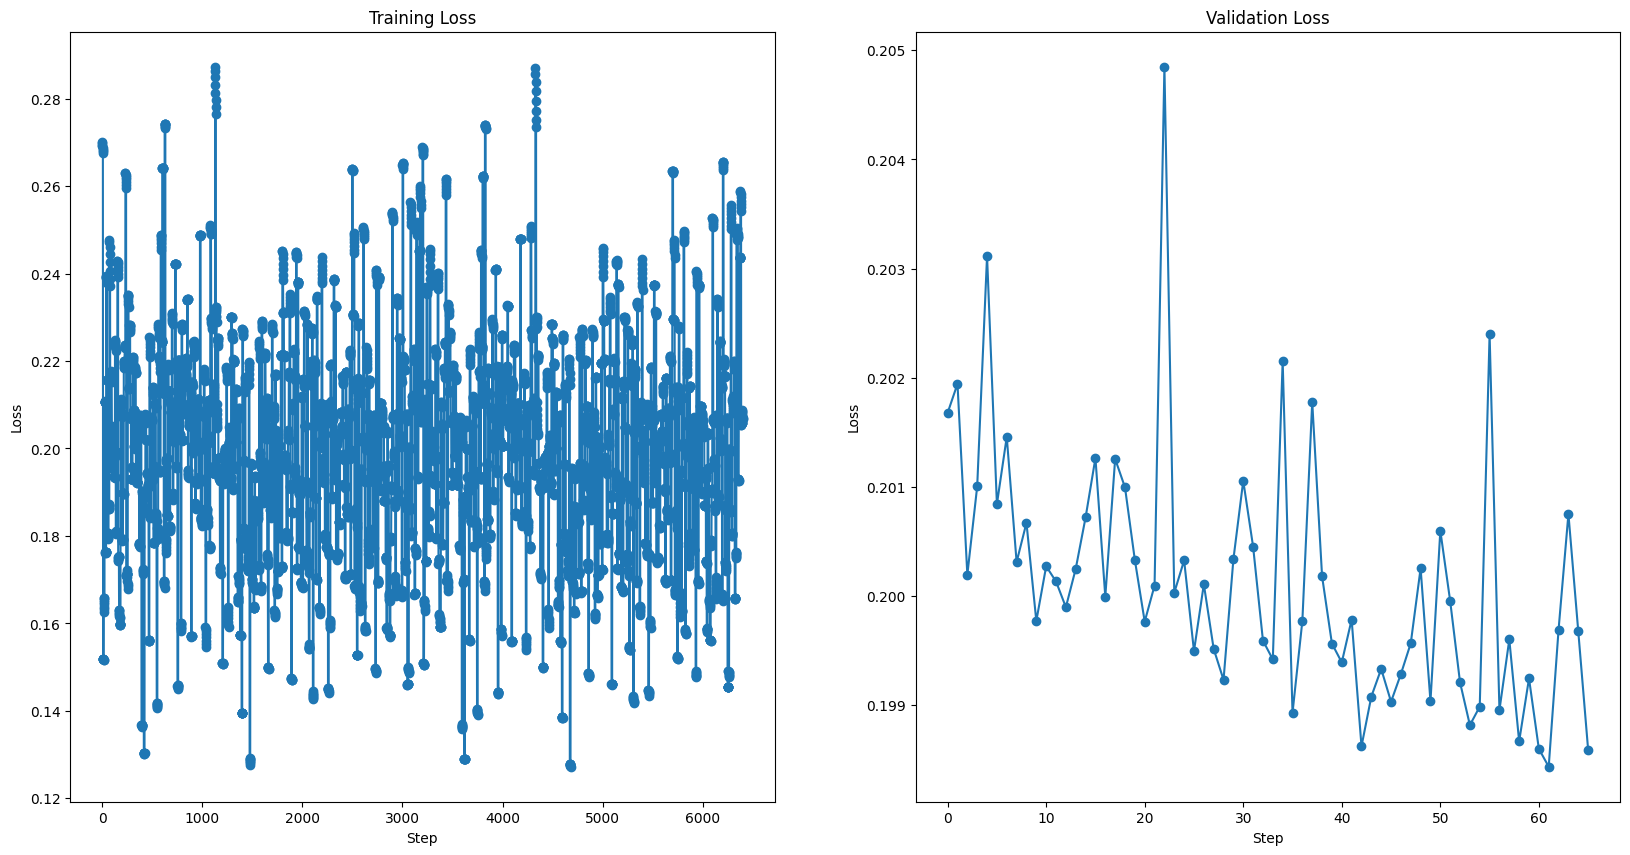

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].plot(losses_train, marker='o')
ax[0].set_title('Training Loss')
ax[0].set_xlabel('Step')
ax[0].set_ylabel('Loss')
ax[1].plot(losses_val, marker='o')
ax[1].set_title('Validation Loss')
ax[1].set_xlabel('Step')
ax[1].set_ylabel('Loss')

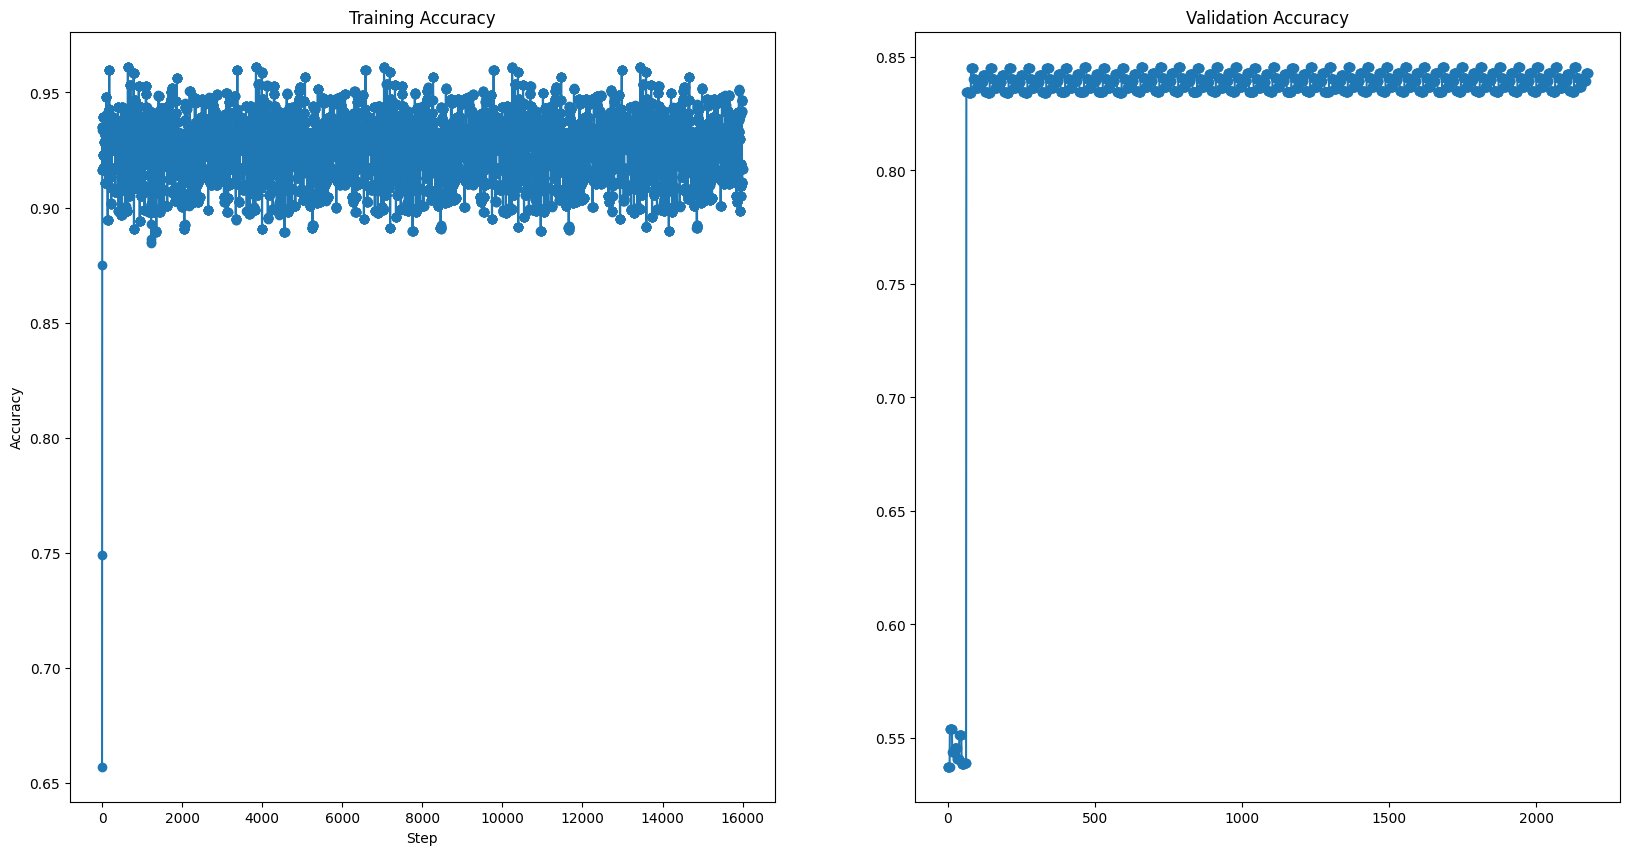

In [23]:
if len(accs_train) > 0:
    fig, ax = plt.subplots(1, 2, figsize=(20, 10))
    ax[0].plot(accs_train, marker='o')
    ax[0].set_title('Training Accuracy')
    ax[0].set_xlabel('Step')
    ax[0].set_ylabel('Accuracy')
    ax[1].plot(accs_val, marker='o')
    ax[1].set_title('Validation Accuracy')
else:
    print("No accuracy data to plot")


Text(0, 0.5, 'Predicted Incorrect Percent')

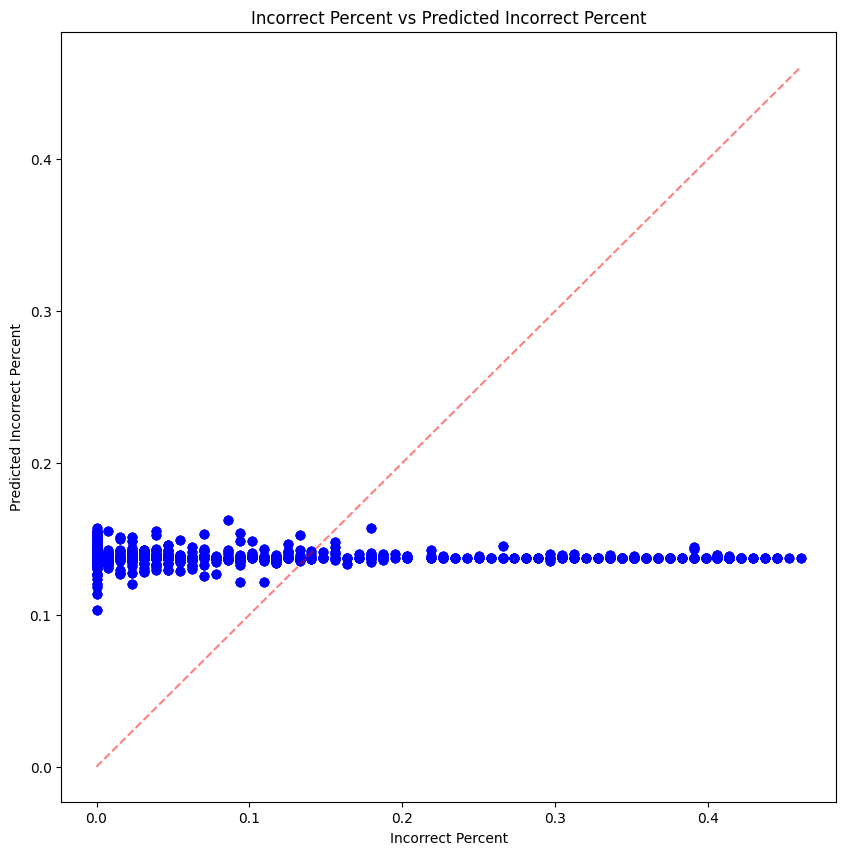

In [61]:
""" 
Scatter plot of incorrect percent vs predicted incorrect percent
""" 
curr_losses_val = []
all_incorrect_percent = []
all_pred_incorrect_percent = []
with torch.no_grad():
    for batch in val_loader:
        x, y = batch[0].to(device).long(), batch[1].to(device).long()
        logits = model(x)
        pred = torch.argmax(logits, dim=-1)
        incorrect_percent = (pred != y).float().mean(dim=1).squeeze(-1)
        x_mlp = (x.float() - X_MEAN) / X_STD
        pred_incorrect_percent = mlp_pred(x_mlp).squeeze(-1)
        all_incorrect_percent.append(incorrect_percent)
        all_pred_incorrect_percent.append(pred_incorrect_percent)
all_incorrect_percent = torch.cat(all_incorrect_percent)
all_pred_incorrect_percent = torch.cat(all_pred_incorrect_percent)

plt.figure(figsize=(10, 10))
plt.scatter(all_incorrect_percent.cpu().numpy(), all_pred_incorrect_percent.cpu().numpy(), c='blue', alpha=0.5)
# plot the line y = x
max_val = max(all_incorrect_percent.max(), all_pred_incorrect_percent.max()).item()
plt.plot([0, max_val], [0, max_val], c='red', alpha=0.5, linestyle='--')
plt.title('Incorrect Percent vs Predicted Incorrect Percent')
plt.xlabel('Incorrect Percent')
plt.ylabel('Predicted Incorrect Percent')

In [64]:
print(X_MEAN)
print(X_STD)

tensor([1.5547, 0.2969, 0.2266, 0.2812, 0.2578, 0.2188, 0.3125, 0.2422, 0.3516,
        0.2500, 0.2734, 0.3047, 0.2812, 0.2969, 0.3828, 0.3125, 0.1797, 0.3438,
        0.2188, 0.2422, 0.3516, 0.2969, 0.3125, 0.2656, 0.3125, 0.3594, 0.3438,
        0.2422, 0.2734, 0.3516, 0.2969, 0.3047, 0.2266, 0.3203, 0.2656, 0.2578,
        0.2422, 0.2188, 0.3516, 0.2344, 0.1719, 0.2969, 0.3047, 0.2578, 0.2812,
        0.3125, 0.2891, 0.2422, 0.3047, 0.2969, 0.2812, 0.3750, 0.2422, 0.2656,
        0.3438, 0.2031, 0.2969, 0.2656, 0.2969, 0.2500, 0.3047, 0.3516, 0.3516,
        0.3281, 0.2266, 0.2188, 0.3047, 0.2578, 0.2812, 0.3203, 0.2656, 0.2578,
        0.2578, 0.2734, 0.2656, 0.2422, 0.3047, 0.3516, 0.2891, 0.2734, 0.2500,
        0.2969, 0.2031, 0.2344, 0.3672, 0.2344, 0.1875, 0.2656, 0.2422, 0.2969,
        0.2422, 0.2656, 0.3203, 0.2891, 0.2734, 0.3359, 0.2500, 0.2500, 0.3672,
        0.2188, 0.3125, 0.2500, 0.3359, 0.2734, 0.2891, 0.2109, 0.3047, 0.2266,
        0.2812, 0.1953, 0.2891, 0.3281, 

# Attention check

In [8]:
batch = next(iter(val_loader))
xv, yv = batch[0].to(device).long(), batch[1].to(device).long()

In [38]:
li, hi = 0, 0
with torch.no_grad():
    logits, intermediates = model(xv, return_intermediates=True)
pred = torch.argmax(logits, dim=-1)
correct_mask = (pred == yv).long()
attn = intermediates.attn_intermediates[li].post_softmax_attn[:, hi]
attn_max_val, _ = attn.max(dim=-1)

attn_max_val, correct_mask = attn_max_val.reshape(-1).float().cpu(), correct_mask.reshape(-1).float().cpu()

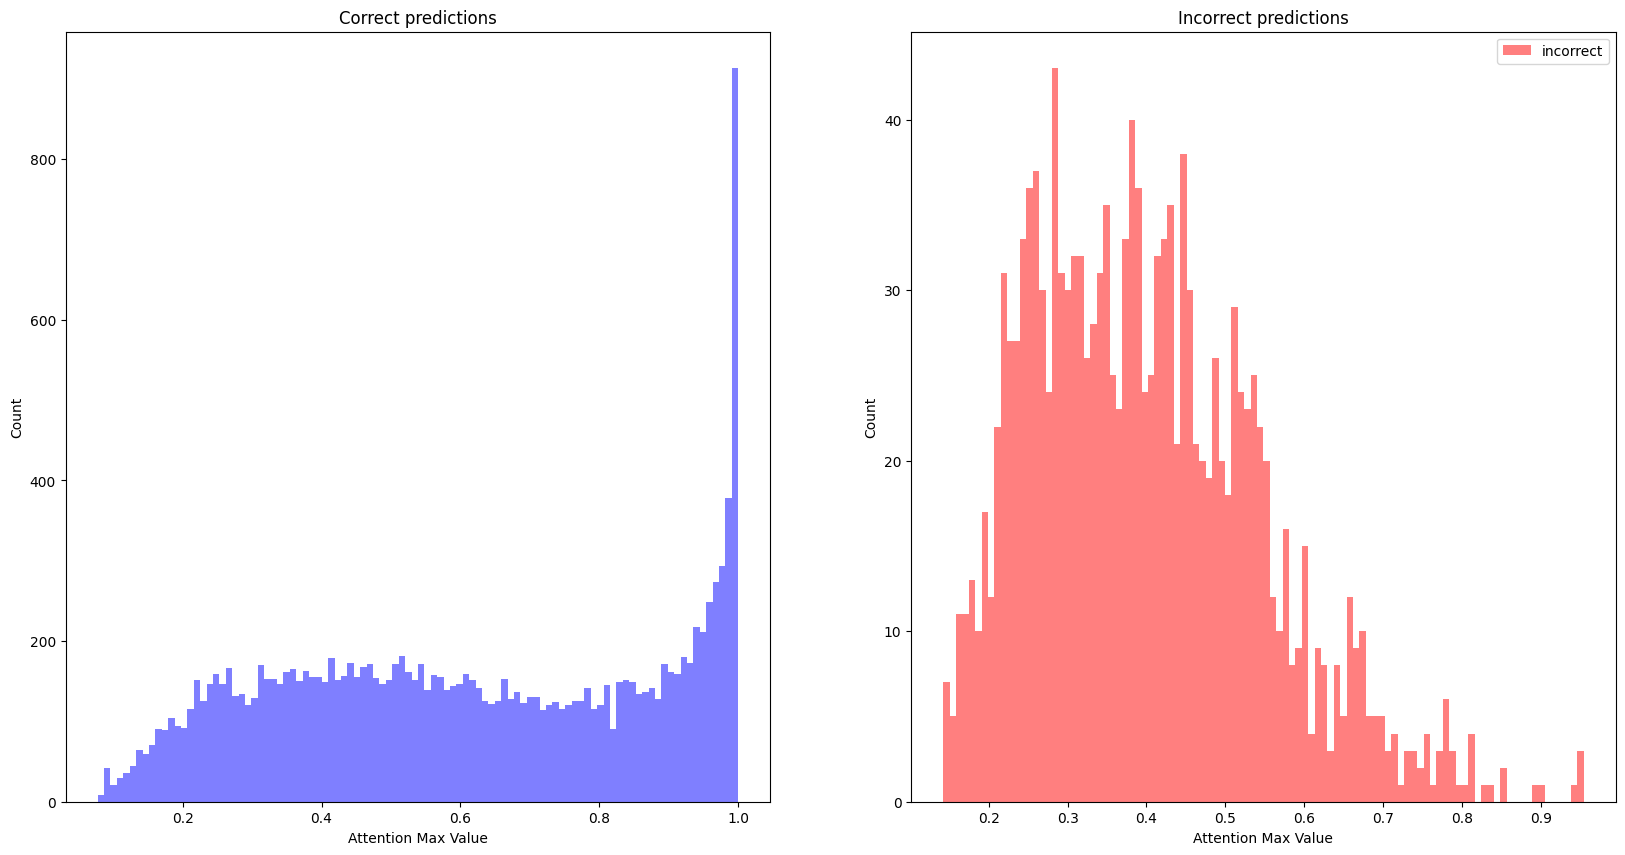

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].hist(attn_max_val[correct_mask == 1], bins=100, alpha=0.5, label='correct', color='blue')
ax[1].hist(attn_max_val[correct_mask == 0], bins=100, alpha=0.5, label='incorrect', color='red')
ax[0].set_title('Correct predictions')
ax[1].set_title('Incorrect predictions')
ax[0].set_xlabel('Attention Max Value')
ax[1].set_xlabel('Attention Max Value')
ax[0].set_ylabel('Count')
ax[1].set_ylabel('Count')
plt.legend()
plt.show()

In [ ]:
attn_max_val = attn_max_val.reshape(xv.shape[0], -1)
correct_mask = correct_mask.reshape(xv.shape[0], -1)

idx = 1
print(attn_max_val[idx])
print(correct_mask[idx])

In [37]:
""" 
Check the correlation between the attention max val and the incorrectness
"""
p, r = pearsonr(attn_max_val.reshape(-1).float().cpu(), correct_mask.reshape(-1).float().cpu())
print(f'attn_max_val vs correctness: corr={p:.4f}, p-value={r}')




attn_max_val vs correctness: corr=0.2329, p-value=1.2623327757837235e-200


In [75]:
correct_mask.shape

torch.Size([128, 128])

0 1
0 4
0 5
0 10
0 15
0 17
0 18
0 19
0 21
0 22
0 23
0 29
0 40
0 41
0 43
0 51
0 52
0 56
0 63
0 64
0 71
0 77
0 81
0 88
0 94
0 99
0 115
0 116
0 118
1 3
1 4
1 8
1 16
1 17
1 18
1 20
1 21
1 35
1 39
1 42
1 44
1 52
1 53
1 57
1 62
1 66
1 81
1 85
1 86
1 95
1 101
1 103
1 105
1 106
1 107
1 109
1 110
1 126
1 127
2 15
2 18
2 44
2 76
3 0
3 12
3 20
3 24
3 26
3 46
3 89
3 98
3 116
4 0
4 4
4 8
4 10
4 13
4 38
4 41
4 44
4 53
4 57
4 66
4 74
4 78
4 82
4 94
4 111
4 120
5 3
5 5
5 10
5 17
5 18
5 19
5 22
5 26
5 27
5 31
5 33
5 41
5 54
5 58
5 60
5 61
5 65
5 67
5 70
5 72
5 78
5 80
5 92
5 93
5 95
5 96
5 100
5 107
5 108
5 110
5 115
5 119
5 123
6 0
6 6
6 9
6 10
6 55
6 69
6 92
6 93
6 99
6 101
6 114
7 23
7 26
7 29
7 40
7 46
7 58
7 60
7 62
7 63
7 65
7 70
7 71
7 82
7 87
7 90
7 105
7 110
8 15
8 18
8 19
8 21
8 32
8 51
8 53
8 57
8 59
8 65
8 73
8 81
8 93
8 96
8 113
8 116
8 123
9 10
9 24
9 33
9 98
10 0
10 19
10 23
10 51
10 59
10 110
10 118
11 13
11 14
11 16
11 20
11 24
11 25
11 27
11 34
11 35
11 36
11 59
11 63
11 64
11 68
11 6

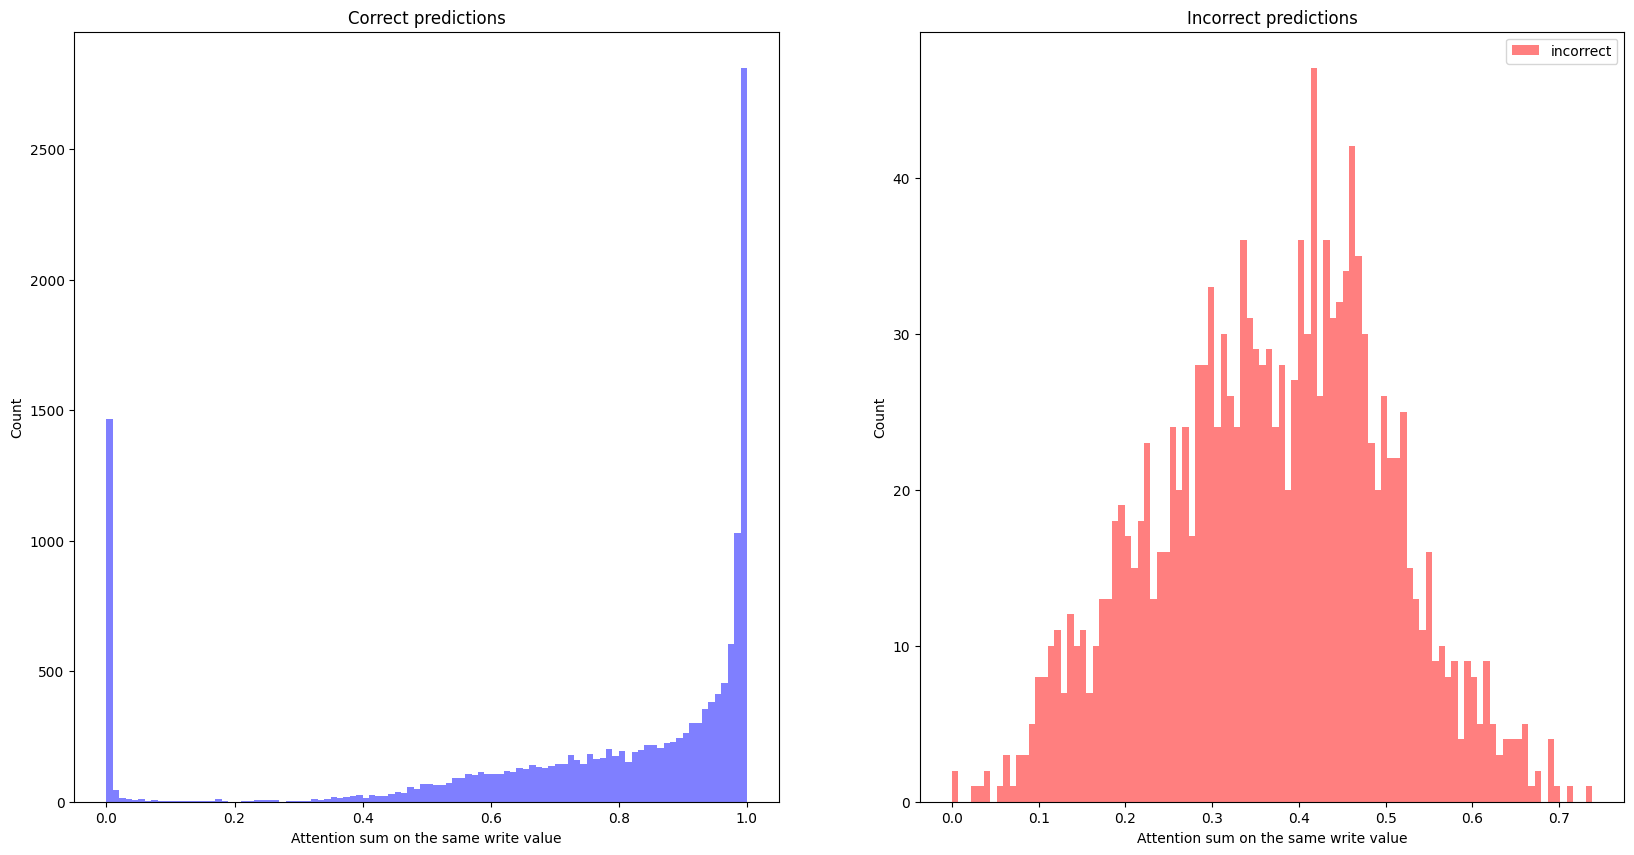

In [77]:
""" 
What about the sum of attention put on all positions of the same write value?
"""

attn_sum = []
for i in range(xv.shape[0]):
    curr_attn_sum = []
    for j in range(xv.shape[1]):
        pos_mask = (xv[i] == yv[i, j]).cpu()
        pos_sum = attn[i, j, pos_mask].sum().item()
        curr_attn_sum.append(pos_sum)
        if correct_mask[i, j] == 1 and pos_sum < 0.1:
            print(i,j)
    attn_sum.append(curr_attn_sum)
attn_sum = np.array(attn_sum)
print(attn_sum.shape)

p, r = pearsonr(attn_sum.reshape(-1), correct_mask.reshape(-1))
print(f'attn_sum vs correctness: corr={p:.4f}, p-value={r}')


fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].hist(attn_sum[correct_mask == 1], bins=100, alpha=0.5, label='correct', color='blue')
ax[1].hist(attn_sum[correct_mask == 0], bins=100, alpha=0.5, label='incorrect', color='red')
ax[0].set_title('Correct predictions')
ax[1].set_title('Incorrect predictions')
ax[0].set_xlabel('Attention sum on the same write value')
ax[1].set_xlabel('Attention sum on the same write value')
ax[0].set_ylabel('Count')
ax[1].set_ylabel('Count')
plt.legend()
plt.show()

In [79]:
print(xv[0])
print(attn[0,4])

tensor([2, 1, 2, 0, 1, 1, 2, 0, 0, 0, 1, 2, 2, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
        0, 0, 0, 0, 2, 1, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 1, 1, 0, 1, 2, 0, 0, 2,
        0, 0, 0, 1, 1, 2, 2, 0, 1, 0, 0, 2, 0, 2, 2, 1, 1, 2, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 0, 2, 1, 2, 2, 0, 1, 0, 0, 0, 2, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0,
        0, 0, 2, 1, 2, 0, 2, 2, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 2, 1, 1, 0, 1, 2,
        2, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')
tensor([1.0100e-08, 4.8000e-07, 9.8336e-09, 6.2839e-01, 1.3008e-07, 1.3450e-07,
        6.8787e-10, 4.2939e-02, 4.0685e-02, 1.1162e-01, 3.3974e-08, 9.5925e-10,
        2.5971e-09, 3.0551e-02, 1.1718e-02, 3.7783e-08, 2.2785e-02, 1.5162e-08,
        2.0824e-08, 1.0846e-08, 8.2317e-04, 1.6747e-08, 6.7939e-09, 3.3829e-09,
        2.2977e-03, 2.2140e-03, 5.4395e-03, 5.8290e-04, 8.6887e-11, 4.1985e-09,
        2.9251e-10, 8.5090e-03, 3.8071e-03, 2.0792e-03, 2.2340e-02, 3.9458e-04,
        3.9058e-04, 2.3153e-03, 8.8577e-11, 1.9470e-03, 1.3720e-09, 9.

# How predictions change across training?

In [12]:
""" 
Are predictions symmetric w.r.t. states? -- pretty symmetric
""" 

accs_1, accs_2 = [], []
for batch in val_loader:
    x, y = batch[0].to(device).long(), batch[1].to(device).long()
    x_reverse = x.clone()
    x_reverse[x==1] = 2
    x_reverse[x==2] = 1 
    y_reverse = y.clone()
    y_reverse[y==1] = 2
    y_reverse[y==2] = 1 
    with torch.no_grad():
        logits = model(x)
        logits_reverse = model(x_reverse)
    pred = torch.argmax(logits, dim=-1)
    pred_reverse = torch.argmax(logits_reverse, dim=-1)
    accs_1.append((pred == y).float().mean().item())
    accs_2.append((pred_reverse == y_reverse).float().mean().item())

print(np.mean(accs_1), np.mean(accs_2))


0.9081344604492188 0.908447265625


In [82]:
""" 
Construct a dataset
""" 

special_pos = np.arange(length)

if 0:
    xs = np.zeros(length)
    xs[0] = 1
    xs[1] = 2

if 0:
    # n_ignores = 80
    xs = np.random.randint(1, 3, length)
    ignore_pos = np.random.choice(length, size=80, replace=False)
    xs[ignore_pos] = 0

if 0: 
    # all 1, except for a few places
    xs = np.ones(length)
    ignore_pos = np.random.choice(length, size=8, replace=False)
    xs[ignore_pos] = 2
    special_pos = ignore_pos

if 1:
    # sparse, but with some stretches of 1s followed by a 2.
    xs = np.zeros(length)
    xs[0] = 2
    start_pos = np.random.randint(0, length - 15)
    stretch_len = 2
    xs[start_pos:start_pos+stretch_len] = 1
    xs[start_pos+stretch_len] = 2
    special_pos = [start_pos+stretch_len]

ys = get_flipflop_labels(xs)
xs, ys = xs.reshape(1, -1), ys.reshape(1, -1)
xs = torch.from_numpy(xs).long().to(device)
ys = torch.from_numpy(ys).long().to(device)


In [63]:
xs

tensor([[2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]], device='cuda:0')

In [21]:
"""
How does the prediction change across training?
"""

curr_ckpt_dir = os.path.join(ckpt_dir, run)
print(curr_ckpt_dir)
ckpts = glob(os.path.join(curr_ckpt_dir, 'step*.pth'))
ckpts = sorted(ckpts, key=lambda x: int(x.split('/')[-1].replace('step', '').replace('.pth', '')))
print(f"Evaluating {len(ckpts)} ckpts")


checkpoints/_1_20250723_002050
Evaluating 40 ckpts


Evaluating checkpoints/_1_20250723_002050/step1.pth
Evaluating checkpoints/_1_20250723_002050/step1000.pth
Evaluating checkpoints/_1_20250723_002050/step2000.pth
Evaluating checkpoints/_1_20250723_002050/step3000.pth
Evaluating checkpoints/_1_20250723_002050/step4000.pth
Evaluating checkpoints/_1_20250723_002050/step5000.pth
Evaluating checkpoints/_1_20250723_002050/step6000.pth
Evaluating checkpoints/_1_20250723_002050/step7000.pth
Evaluating checkpoints/_1_20250723_002050/step8000.pth
Evaluating checkpoints/_1_20250723_002050/step9000.pth
Evaluating checkpoints/_1_20250723_002050/step10000.pth
Evaluating checkpoints/_1_20250723_002050/step11000.pth
Evaluating checkpoints/_1_20250723_002050/step12000.pth
Evaluating checkpoints/_1_20250723_002050/step13000.pth
Evaluating checkpoints/_1_20250723_002050/step14000.pth
Evaluating checkpoints/_1_20250723_002050/step15000.pth
Evaluating checkpoints/_1_20250723_002050/step16000.pth
Evaluating checkpoints/_1_20250723_002050/step17000.pth
Evalu

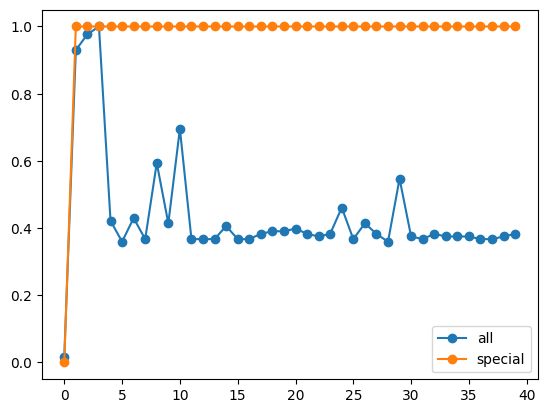

In [83]:
logit_idx = 44

all_logits = []
accs = []
accs_on_special_pos = []
correct_masks = []
for ckpt in ckpts:
    print(f"Evaluating {ckpt}")
    model.load_state_dict(torch.load(ckpt))
    with torch.no_grad():
        logits = model(xs)
        pred = torch.argmax(logits, dim=-1)
        correct_mask = (pred == ys).long().cpu()
        correct_masks.append(correct_mask)
        acc = correct_mask.float().mean().item()
        accs.append(acc)
        acc_on_special_pos = correct_mask[0, special_pos].float().mean().item()
        accs_on_special_pos.append(acc_on_special_pos)
        all_logits.append(logits[:, logit_idx])
all_logits = torch.cat(all_logits, dim=0)
print(all_logits.shape)
correct_masks = torch.cat(correct_masks, dim=0)

plt.plot(accs, marker='o', label='all')
plt.plot(accs_on_special_pos, marker='o', label='special')
plt.legend()
plt.show()

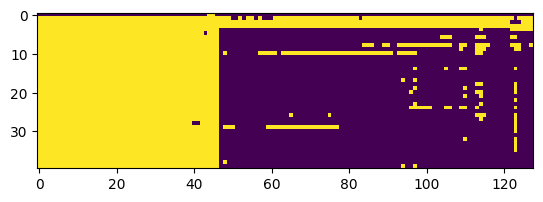

In [84]:
plt.imshow(correct_masks.numpy())

In [75]:
xs[0]

tensor([2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')

In [52]:
start_pos 

64

tensor(2, device='cuda:0')


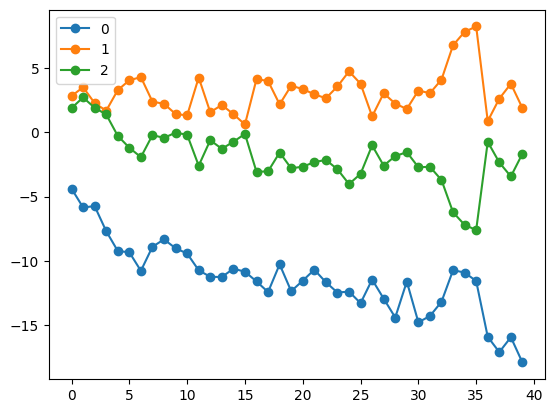

In [36]:
all_logits_npy = all_logits.cpu().numpy()
# all_logits_npy = all_logits

print(ys[0, logit_idx])
plt.plot(all_logits_npy[:, 0], label='0', marker='o')
plt.plot(all_logits_npy[:, 1], label='1', marker='o')
plt.plot(all_logits_npy[:, 2], label='2', marker='o')
plt.legend()
plt.show()




In [38]:
xs[0, 40:44]

tensor([1, 1, 1, 2], device='cuda:0')